# Band Gap Prediction with Deep Learning
## A Three-Stage MLP Workshop

**Dataset:** `matbench_expt_gap` — experimental band gaps (eV) for inorganic compounds  
**Goal:** Predict band gap from chemical composition using a Multi-Layer Perceptron (MLP)

Each stage adds one cluster of DL best-practices. Watch the loss curve and MAE improve at each step.

## Shared Setup
*Run once. All three model stages share this featurized data.*

In [1]:
import copy, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matminer.datasets import load_dataset
from matminer.featurizers.conversions import StrToComposition
from matminer.featurizers.composition import ElementProperty

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

/home/bikal/miniconda3/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Device: cuda


### 1. Load Dataset
`matbench_expt_gap` contains ~4,600 experimentally measured band gaps.  
We keep only positive values (insulators/semiconductors) — metals (gap = 0) are a different prediction problem.

In [2]:
df = load_dataset("matbench_expt_gap")
df = df[df["gap expt"] > 0].reset_index(drop=True)
print(f"Samples with positive band gap: {len(df)}")
print(df["gap expt"].describe().round(3))

Samples with positive band gap: 2154
count    2154.000
mean        2.086
std         1.465
min         0.020
25%         1.040
50%         1.930
75%         2.700
max        11.700
Name: gap expt, dtype: float64


### 2. Featurize with Magpie
Compositions like "GaAs" or "TiO2" are strings — neural networks need numbers.  
**Magpie** (Materials Agnostic Platform for Informatics and Exploration) converts each formula into ~130 elemental statistics (mean atomic radius, electronegativity, etc.).

In [3]:
str_to_comp = StrToComposition(target_col_id="composition_obj")
data = str_to_comp.featurize_dataframe(df.copy(), col_id="composition")

featurizer = ElementProperty.from_preset("magpie")
data = featurizer.featurize_dataframe(data, col_id="composition_obj")
data = data.dropna().reset_index(drop=True)

print(f"Shape after featurization: {data.shape}")

StrToComposition:   0%|          | 0/2154 [00:00<?, ?it/s]

/home/bikal/miniconda3/lib/python3.10/site-packages/matminer/utils/data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


ElementProperty:   0%|          | 0/2154 [00:00<?, ?it/s]

Shape after featurization: (2154, 135)


### 3. Split and Scale Features
Standard 70/15/15 train/val/test split.  
`StandardScaler` on X ensures all ~130 features are on the same scale — prevents large-magnitude features dominating gradient updates.  
**Important:** fit the scaler on train only, then transform val/test. Otherwise you leak information.

In [4]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove("gap expt")

X = data[numeric_cols].values.astype(np.float32)
y_raw = data["gap expt"].values.astype(np.float32).reshape(-1, 1)

X_train, X_temp, y_train, y_temp = train_test_split(X, y_raw, test_size=0.30, random_state=SEED)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

X_scaler = StandardScaler()
X_train_s = X_scaler.fit_transform(X_train)
X_val_s   = X_scaler.transform(X_val)
X_test_s  = X_scaler.transform(X_test)

# Clip extreme outliers from Magpie features (a few rare compounds have atypical
# elemental statistics that produce multi-million z-scores after scaling).
# Clamping to ±10 σ keeps all physically meaningful variance while preventing
# numerical instability in the training and validation loss.
CLIP = 10.0
X_train_s = np.clip(X_train_s, -CLIP, CLIP)
X_val_s   = np.clip(X_val_s,   -CLIP, CLIP)
X_test_s  = np.clip(X_test_s,  -CLIP, CLIP)

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_s,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)

n_features = X_train.shape[1]
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Number of Magpie features: {n_features}")

Train: (1507, 132) | Val: (323, 132) | Test: (324, 132)
Number of Magpie features: 132


---
## Stage 1 — Naive MLP

**Materials science view:** Let's try the simplest possible network on raw band gap values.  
**ML view:** This shows what happens without any regularization or data preprocessing — the baseline to beat.

**Architecture:** `Linear(n→128) → ReLU → Linear(128→1)`  
**New concepts:** forward pass, MSE loss, Adam optimizer, learning curve

In [5]:
# y as raw eV — no transform
y_train_1t = torch.tensor(y_train, dtype=torch.float32)
y_val_1t   = torch.tensor(y_val,   dtype=torch.float32)

train_loader_1 = DataLoader(TensorDataset(X_train_t, y_train_1t), batch_size=64, shuffle=True)
val_loader_1   = DataLoader(TensorDataset(X_val_t, y_val_1t),     batch_size=256, shuffle=False)

class NaiveMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.net(x)

model_1     = NaiveMLP(n_features).to(device)
criterion_1 = nn.MSELoss()
optimizer_1 = torch.optim.Adam(model_1.parameters(), lr=1e-3)

train_losses_1, val_losses_1 = [], []

for epoch in range(100):
    model_1.train()
    tl = 0.0
    for xb, yb in train_loader_1:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_1.zero_grad()
        loss = criterion_1(model_1(xb), yb)
        loss.backward()
        optimizer_1.step()
        tl += loss.item() * xb.size(0)
    train_losses_1.append(tl / len(train_loader_1.dataset))

    model_1.eval()
    vl = 0.0
    with torch.no_grad():
        for xb, yb in val_loader_1:
            xb, yb = xb.to(device), yb.to(device)
            vl += criterion_1(model_1(xb), yb).item() * xb.size(0)
    val_losses_1.append(vl / len(val_loader_1.dataset))

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1:3d} | train MSE {train_losses_1[-1]:.4f} | val MSE {val_losses_1[-1]:.4f}")

Epoch  25 | train MSE 0.2812 | val MSE 0.5174


Epoch  50 | train MSE 0.1620 | val MSE 0.5323


Epoch  75 | train MSE 0.1234 | val MSE 0.5671


Epoch 100 | train MSE 0.0963 | val MSE 0.5719


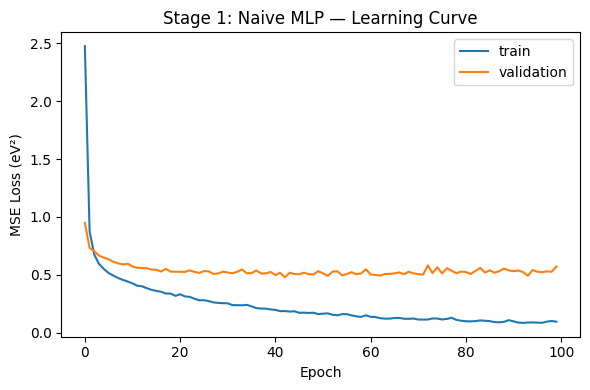

Stage 1 — Test MAE: 0.4407 eV  |  R²: 0.7789
Notice: noisy curve, large MAE, train loss much lower than val → overfitting


In [6]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_1, label="train")
plt.plot(val_losses_1,   label="validation")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss (eV²)")
plt.title("Stage 1: Naive MLP — Learning Curve")
plt.legend(); plt.tight_layout(); plt.show()

model_1.eval()
with torch.no_grad():
    test_pred_1 = model_1(X_test_t.to(device)).cpu().numpy().ravel()

mae_1 = mean_absolute_error(y_test.ravel(), test_pred_1)
r2_1  = r2_score(y_test.ravel(), test_pred_1)
print(f"Stage 1 — Test MAE: {mae_1:.4f} eV  |  R²: {r2_1:.4f}")
print("Notice: noisy curve, large MAE, train loss much lower than val → overfitting")

---
## Stage 2 — Regularized MLP

**Stage 1→2 transition:**  
Band gap values are right-skewed (most compounds cluster near 0–3 eV, a few exceed 10 eV).  
MSE penalizes large errors quadratically, so the model chases rare high-gap outliers.  
`log1p` compresses the tail → more uniform target distribution → stabler training.

Dropout randomly zeros neurons during training, preventing co-adaptation → less overfitting.  
AdamW adds weight decay (L2 penalty on weights) as a second regularization layer.

**New concepts:** log1p target transform, Dropout, AdamW + weight decay

In [7]:
# log1p transform + StandardScaler on y
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)

y_scaler = StandardScaler()
y_train_2s = y_scaler.fit_transform(y_train_log)
y_val_2s   = y_scaler.transform(y_val_log)

y_train_2t = torch.tensor(y_train_2s, dtype=torch.float32)
y_val_2t   = torch.tensor(y_val_2s,   dtype=torch.float32)

train_loader_2 = DataLoader(TensorDataset(X_train_t, y_train_2t), batch_size=64, shuffle=True)
val_loader_2   = DataLoader(TensorDataset(X_val_t, y_val_2t),     batch_size=256, shuffle=False)

class RegularizedMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.net(x)

model_2     = RegularizedMLP(n_features).to(device)
criterion_2 = nn.MSELoss()
optimizer_2 = torch.optim.AdamW(model_2.parameters(), lr=1e-3, weight_decay=1e-4)

train_losses_2, val_losses_2 = [], []

for epoch in range(100):
    model_2.train()
    tl = 0.0
    for xb, yb in train_loader_2:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_2.zero_grad()
        loss = criterion_2(model_2(xb), yb)
        loss.backward()
        optimizer_2.step()
        tl += loss.item() * xb.size(0)
    train_losses_2.append(tl / len(train_loader_2.dataset))

    model_2.eval()
    vl = 0.0
    with torch.no_grad():
        for xb, yb in val_loader_2:
            xb, yb = xb.to(device), yb.to(device)
            vl += criterion_2(model_2(xb), yb).item() * xb.size(0)
    val_losses_2.append(vl / len(val_loader_2.dataset))

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1:3d} | train MSE {train_losses_2[-1]:.4f} | val MSE {val_losses_2[-1]:.4f}")

Epoch  25 | train MSE 0.1700 | val MSE 0.2782


Epoch  50 | train MSE 0.1329 | val MSE 0.2724


Epoch  75 | train MSE 0.1111 | val MSE 0.2570


Epoch 100 | train MSE 0.1047 | val MSE 0.2585


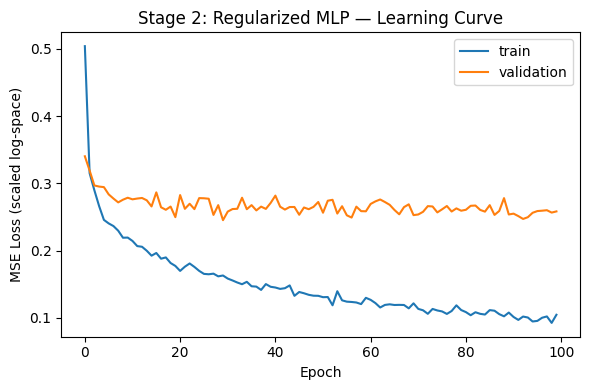

Stage 2 — Test MAE: 0.4152 eV  |  R²: 0.8040
Notice: smoother curve, train/val gap narrowed, MAE improved vs Stage 1


In [8]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_2, label="train")
plt.plot(val_losses_2,   label="validation")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss (scaled log-space)")
plt.title("Stage 2: Regularized MLP — Learning Curve")
plt.legend(); plt.tight_layout(); plt.show()

model_2.eval()
with torch.no_grad():
    test_pred_2s = model_2(X_test_t.to(device)).cpu().numpy()

test_pred_2 = np.expm1(y_scaler.inverse_transform(test_pred_2s)).ravel()
mae_2 = mean_absolute_error(y_test.ravel(), test_pred_2)
r2_2  = r2_score(y_test.ravel(), test_pred_2)
print(f"Stage 2 — Test MAE: {mae_2:.4f} eV  |  R²: {r2_2:.4f}")
print("Notice: smoother curve, train/val gap narrowed, MAE improved vs Stage 1")

---
## Stage 3 — Full Pipeline MLP

**Stage 2→3 transition:**  
The learning rate never adapts in Stage 2 — we waste epochs after convergence and may miss the minimum.  
`ReduceLROnPlateau` halves the LR when val loss plateaus → finer convergence.  
Early stopping halts training when val loss stops improving → no wasted compute, less overfitting.  
BatchNorm normalizes layer activations → stabler gradients, faster convergence.  
Gradient clipping prevents occasional exploding gradients from destabilizing training.

**New concepts:** BatchNorm, ReduceLROnPlateau, early stopping, gradient clipping, HuberLoss

In [9]:
# Reuse y tensors from Stage 2 (same log1p + StandardScaler)
train_loader_3 = DataLoader(TensorDataset(X_train_t, y_train_2t), batch_size=64, shuffle=True)
val_loader_3   = DataLoader(TensorDataset(X_val_t,   y_val_2t),   batch_size=256, shuffle=False)

class FullMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.net(x)

model_3     = FullMLP(n_features).to(device)
criterion_3 = nn.HuberLoss(delta=1.0)
optimizer_3 = torch.optim.AdamW(model_3.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_3, mode="min", factor=0.5, patience=10
)

patience_3 = 25
best_val_3, best_state_3, wait_3 = np.inf, None, 0
train_losses_3, val_losses_3 = [], []

for epoch in range(300):
    model_3.train()
    tl = 0.0
    for xb, yb in train_loader_3:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_3.zero_grad()
        loss = criterion_3(model_3(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_3.parameters(), max_norm=5.0)
        optimizer_3.step()
        tl += loss.item() * xb.size(0)
    train_losses_3.append(tl / len(train_loader_3.dataset))

    model_3.eval()
    vl = 0.0
    with torch.no_grad():
        for xb, yb in val_loader_3:
            xb, yb = xb.to(device), yb.to(device)
            vl += criterion_3(model_3(xb), yb).item() * xb.size(0)
    vl /= len(val_loader_3.dataset)
    val_losses_3.append(vl)
    scheduler_3.step(vl)

    if vl < best_val_3:
        best_val_3 = vl
        best_state_3 = copy.deepcopy(model_3.state_dict())
        wait_3 = 0
    else:
        wait_3 += 1

    if (epoch + 1) % 25 == 0:
        lr = optimizer_3.param_groups[0]["lr"]
        print(f"Epoch {epoch+1:3d} | train {train_losses_3[-1]:.4f} | val {vl:.4f} | lr {lr:.2e}")

    if wait_3 >= patience_3:
        print(f"Early stopping at epoch {epoch+1}")
        break

model_3.load_state_dict(best_state_3)
print(f"Best val loss: {best_val_3:.4f}")

Epoch  25 | train 0.0580 | val 0.1162 | lr 1.00e-03


Epoch  50 | train 0.0417 | val 0.1077 | lr 1.00e-03


Epoch  75 | train 0.0287 | val 0.0976 | lr 5.00e-04


Epoch 100 | train 0.0230 | val 0.0949 | lr 2.50e-04


Epoch 125 | train 0.0211 | val 0.0948 | lr 1.25e-04


Epoch 150 | train 0.0192 | val 0.0945 | lr 3.13e-05
Early stopping at epoch 151
Best val loss: 0.0942


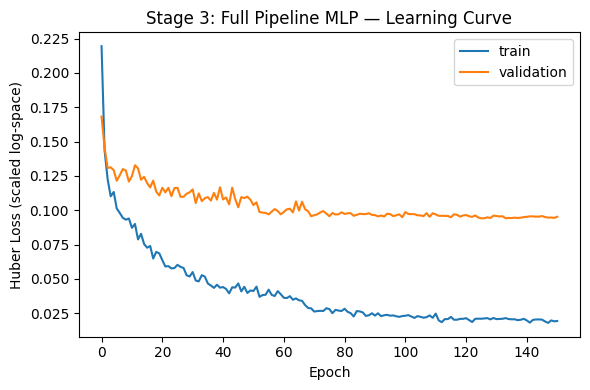

Stage 3 — Test MAE: 0.3745 eV  |  R²: 0.8184
Notice: stable curve, best MAE, train and val track closely


In [10]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses_3, label="train")
plt.plot(val_losses_3,   label="validation")
plt.xlabel("Epoch"); plt.ylabel("Huber Loss (scaled log-space)")
plt.title("Stage 3: Full Pipeline MLP — Learning Curve")
plt.legend(); plt.tight_layout(); plt.show()

model_3.eval()
with torch.no_grad():
    test_pred_3s = model_3(X_test_t.to(device)).cpu().numpy()

test_pred_3 = np.expm1(y_scaler.inverse_transform(test_pred_3s)).ravel()
mae_3 = mean_absolute_error(y_test.ravel(), test_pred_3)
r2_3  = r2_score(y_test.ravel(), test_pred_3)
print(f"Stage 3 — Test MAE: {mae_3:.4f} eV  |  R²: {r2_3:.4f}")
print("Notice: stable curve, best MAE, train and val track closely")

---
## Summary: What Each Stage Added

| Stage | Model | New DL Concepts | MAE (eV) | R² |
|-------|-------|-----------------|----------|----|
| 1 | Naive MLP | Forward pass, MSE loss, Adam | — | — |
| 2 | + Regularization | log1p transform, Dropout, AdamW | — | — |
| 3 | Full pipeline | BatchNorm, LR scheduler, early stopping, gradient clipping | — | — |

*(Numbers filled in at runtime below)*

In [11]:
print("\n" + "="*68)
print(f"{'Stage':<7} {'Model':<22} {'New Concepts':<28} {'MAE (eV)':>9} {'R²':>7}")
print("="*68)
print(f"{'1':<7} {'Naive MLP':<22} {'MSE, Adam (no tricks)':<28} {mae_1:>9.4f} {r2_1:>7.4f}")
print(f"{'2':<7} {'+ Regularization':<22} {'log1p, Dropout, AdamW':<28} {mae_2:>9.4f} {r2_2:>7.4f}")
print(f"{'3':<7} {'Full pipeline':<22} {'BN, LR sched, early stop':<28} {mae_3:>9.4f} {r2_3:>7.4f}")
print("="*68)


Stage   Model                  New Concepts                  MAE (eV)      R²
1       Naive MLP              MSE, Adam (no tricks)           0.4407  0.7789
2       + Regularization       log1p, Dropout, AdamW           0.4152  0.8040
3       Full pipeline          BN, LR sched, early stop        0.3745  0.8184


### Stage 3 Parity Plot
Each dot is one test compound. A perfect model would put all dots on the dashed diagonal.

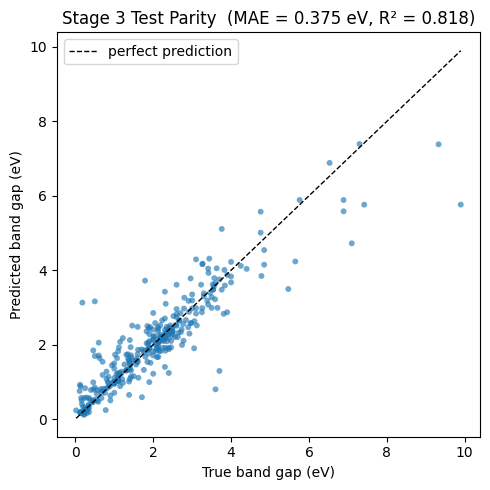

In [12]:
y_true = y_test.ravel()
plt.figure(figsize=(5, 5))
plt.scatter(y_true, test_pred_3, s=18, alpha=0.65, edgecolors="none")
lo = min(y_true.min(), test_pred_3.min())
hi = max(y_true.max(), test_pred_3.max())
plt.plot([lo, hi], [lo, hi], "k--", lw=1, label="perfect prediction")
plt.xlabel("True band gap (eV)")
plt.ylabel("Predicted band gap (eV)")
plt.title(f"Stage 3 Test Parity  (MAE = {mae_3:.3f} eV, R² = {r2_3:.3f})")
plt.legend(); plt.tight_layout(); plt.show()